In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats

from statsmodels.stats.multitest import multipletests
import anndata as ad
import scanpy as sc
import muon as mu
from muon import atac as ac
import scipy.sparse as sp

sc.settings.verbosity = 2
sc.settings.set_figure_params(dpi=100, facecolor="white", frameon=False)
mpl.rcParams["figure.figsize"] = (6, 5)

print(f"scanpy  {sc.__version__}")
print(f"anndata {ad.__version__}")
print(f"muon    {mu.__version__}")

scanpy  1.9.6
anndata 0.9.2
muon    0.1.5


In [ ]:
RNA_PATH = "../data/raw/SEAAD_MTG_RNAseq_all-nuclei.2024-02-13.h5ad"
atac_df = pd.read_csv("../data/processed/count_matrix.txt", sep='\t', index_col=0)
OUT_DIR_RNA = "../data/raw/SEA-AD/MTG_scRNA/results_aCM_AD"
os.makedirs(OUT_DIR_RNA, exist_ok=True)

adata_rna = sc.read_h5ad(RNA_PATH)
print(adata_rna)

# Donors total
donors_rna = adata_rna.obs['Donor ID'].unique()
print(f"\nDonors RNA total: {len(donors_rna)}")

# Donors avec PPS
has_pps = adata_rna.obs['Continuous Pseudo-progression Score'].notna()
donors_rna_pps = adata_rna.obs[has_pps]['Donor ID'].unique()
print(f"Donors RNA avec PPS: {len(donors_rna_pps)}")

In [ ]:
gene_hits = pd.read_csv(f'../data/processed/results_aCM_AD/78cms_to_genes_CLEAN.csv')
genes_of_interest = gene_hits['gene_name'].unique().tolist()
print(f"Gènes à valider: {len(genes_of_interest)}")
donors_atac_60 = atac_df.columns.tolist()
print(f"Nb donors ATAC: {len(donors_atac_60)}")

Gènes à valider: 86
Nb donors ATAC: 60


In [ ]:
# Calcule métriques QC
adata_rna.var['mt'] = adata_rna.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata_rna, 
                           qc_vars=['mt'], 
                           percent_top=None, 
                           log1p=True, 
                           inplace=True)

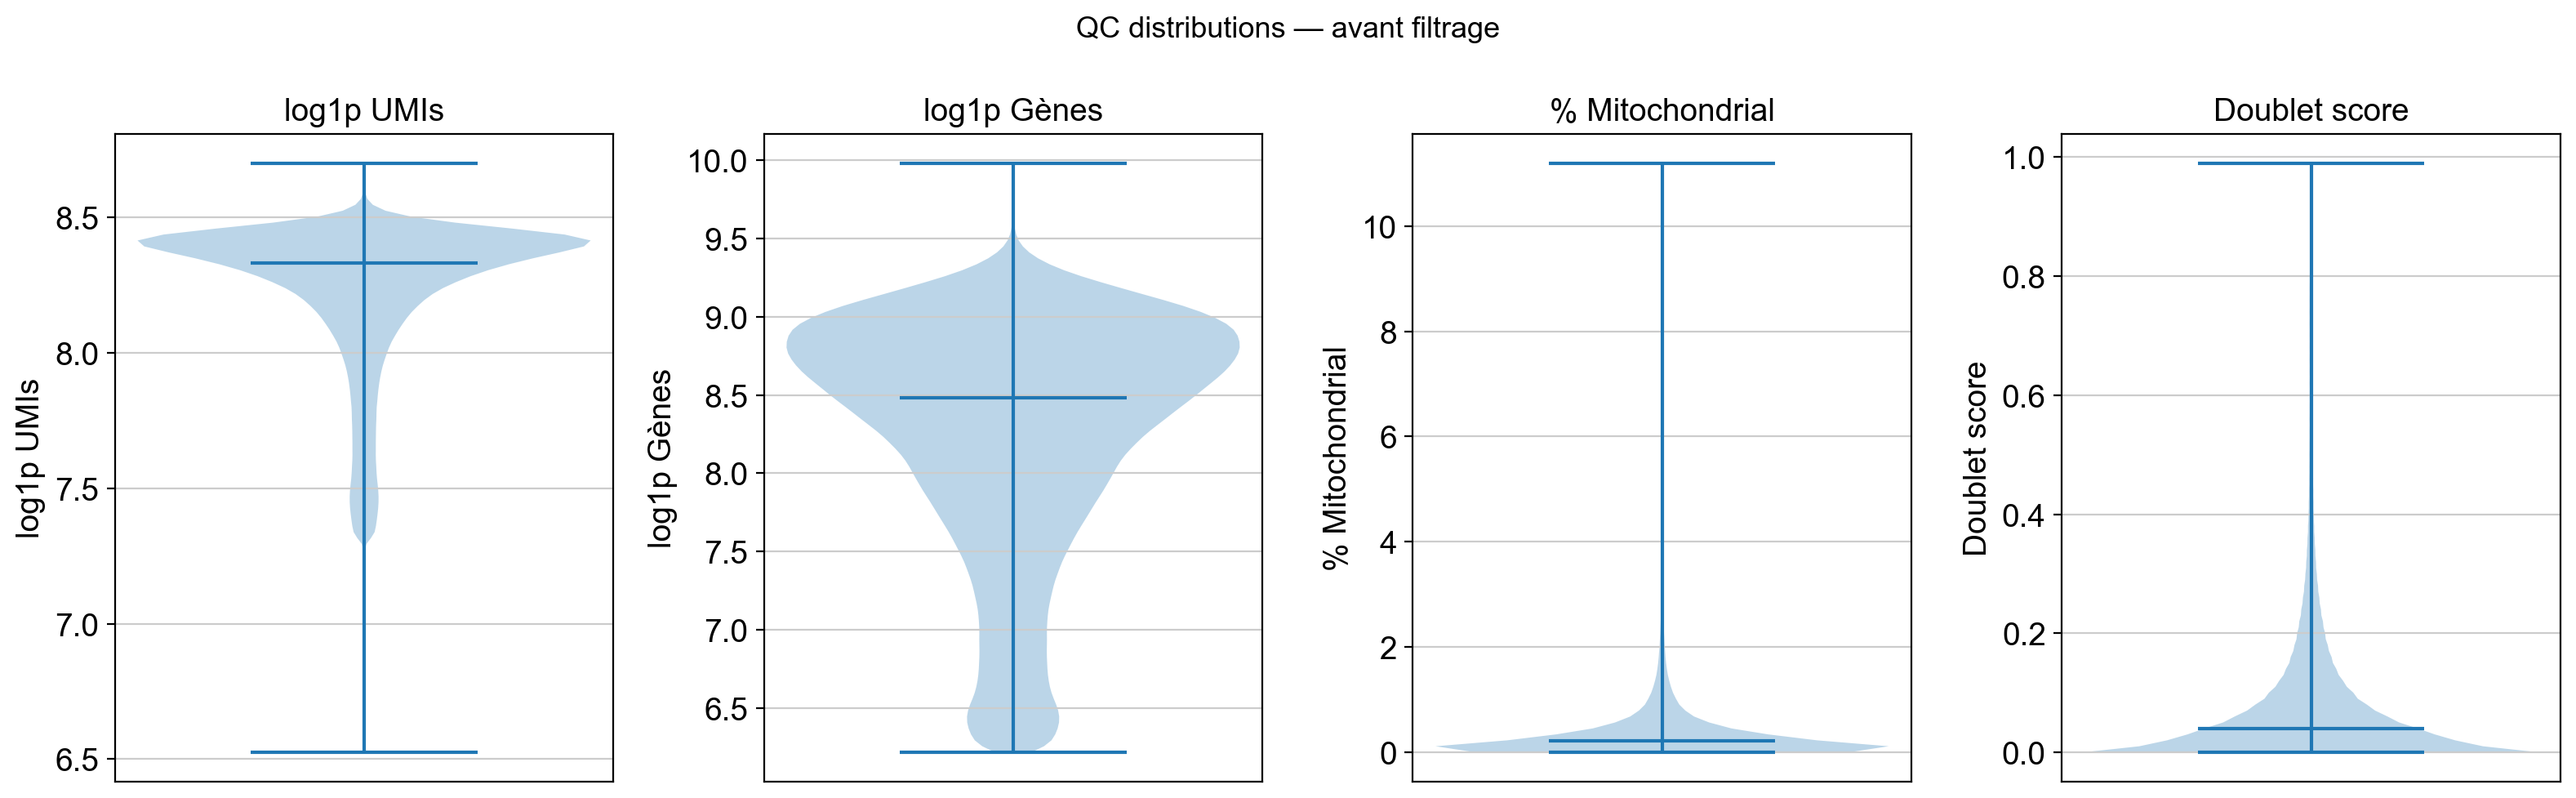

       log1p_total_counts  log1p_n_genes_by_counts  pct_counts_mt  \
count         1957283.000              1957283.000    1957283.000   
mean                8.228                    8.269          0.374   
std                 0.276                    0.764          0.506   
min                 6.526                    6.217          0.000   
25%                 8.162                    7.871          0.085   
50%                 8.332                    8.480          0.214   
75%                 8.409                    8.843          0.452   
max                 8.699                    9.982         11.195   

       Doublet score  
count    1957283.000  
mean           0.090  
std            0.140  
min            0.000  
25%            0.010  
50%            0.040  
75%            0.106  
max            0.990  


In [ ]:
# Violin plots QC (style classique scanpy)
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metrics = [
    ('log1p_total_counts',   'log1p UMIs',         'steelblue'),
    ('log1p_n_genes_by_counts', 'log1p Gènes',      'steelblue'),
    ('pct_counts_mt',        '% Mitochondrial',    'tomato'),
    ('Doublet score',        'Doublet score',       'orange'),
]

for ax, (col, label, color) in zip(axes, metrics):
    ax.violinplot(adata_rna.obs[col].dropna(), showmedians=True)
    ax.set_title(label)
    ax.set_xticks([])
    ax.set_ylabel(label)

plt.suptitle('QC distributions — avant filtrage', fontsize=13)
plt.tight_layout()
plt.show()

# Stats résumées
print(adata_rna.obs[['log1p_total_counts','log1p_n_genes_by_counts',
                      'pct_counts_mt','Doublet score']].describe().round(3))


In [ ]:
import gc

thresholds = {
    'log1p_total_counts'       : ('min', 7.0),
    'log1p_n_genes_by_counts'  : ('min', 7.5),
    'pct_counts_mt'            : ('max', 5.0),
    'Doublet score'            : ('max', 0.3),
}

print(f"Avant QC: {adata_rna.n_obs:,} cellules | {adata_rna.obs['Donor ID'].nunique()} donors\n")

# 1. Masque QC (comme tu faisais)
mask_qc = pd.Series(True, index=adata_rna.obs_names)
for col, (direction, val) in thresholds.items():
    vals = adata_rna.obs[col]
    crit = (vals >= val) if direction == 'min' else (vals <= val)
    crit = crit.fillna(False)
    n_fail = (~crit).sum()
    print(f"{col:<35} {direction}={val} → exclut {n_fail:>7,} ({n_fail/adata_rna.n_obs*100:.1f}%)")
    mask_qc &= crit

# 2. Masque Neurones + Masque PPS
print("\nClasses disponibles avant filtre neurones:")
print(adata_rna.obs['Class'].value_counts())

mask_neu = adata_rna.obs['Class'].str.contains('Neuronal', na=False)
mask_pps = adata_rna.obs['Continuous Pseudo-progression Score'].notna()

# 3. Combine TOUS les filtres en un seul masque global
mask_final = mask_qc & mask_neu & mask_pps

# 4. NE FAIT QU'UNE SEULE COPIE de l'objet final
adata_neu = adata_rna[mask_final].copy()

# 5. SUPPRIME le gros objet initial et force le nettoyage de la RAM
del adata_rna 
gc.collect()

print(f"\n✅ Après filtrage global (QC + Neurones + PPS): {adata_neu.n_obs:,} cellules")
print(f"Donors restants: {adata_neu.obs['Donor ID'].nunique()}")


Avant QC: 1,957,283 cellules | 89 donors

log1p_total_counts                  min=7.0 → exclut     216 (0.0%)
log1p_n_genes_by_counts             min=7.5 → exclut 322,261 (16.5%)
pct_counts_mt                       max=5.0 → exclut     989 (0.1%)
Doublet score                       max=0.3 → exclut 130,739 (6.7%)

Classes disponibles avant filtre neurones:
Class
Neuronal: Glutamatergic        1044002
Non-neuronal and Non-neural     460735
Neuronal: GABAergic             452546
Name: count, dtype: int64



✅ Après filtrage global (QC + Neurones + PPS): 1,082,591 cellules
Donors restants: 84


In [ ]:
print("Création du pseudobulk")

donors = adata_neu.obs['Donor ID'].unique()
pb_data = {}

for donor in donors:
    # Récupère l'index des cellules de ce donneur
    donor_mask = (adata_neu.obs['Donor ID'] == donor).values
    
    # Fait la somme des colonnes (gènes) pour ces cellules
    if sp.issparse(adata_neu.X):
        # .A1 aplatit le résultat en un array 1D classique
        donor_sum = adata_neu.X[donor_mask].sum(axis=0).A1 
    else:
        donor_sum = adata_neu.X[donor_mask].sum(axis=0)
        
    pb_data[donor] = donor_sum

#DataFrame final (Lignes = Gènes, Colonnes = Donors)
pb_df = pd.DataFrame(pb_data, index=adata_neu.var_names)

print(f"\nPseudobulkage finito")
print(f"Shape : {pb_df.shape} (Nb gènes x Nb donors)")

# On sauvegarde pour ne plus jamais avoir à refaire ça
pb_df.to_csv(f'{OUT_DIR_RNA}/pseudobulk_neurons_snRNA.csv')
print(f"Fichier sauvegardé : {OUT_DIR_RNA}/pseudobulk_neurons_snRNA.csv")


Création du pseudobulk

Pseudobulkage finito
Shape : (36601, 84) (Nb gènes x Nb donors)
Fichier sauvegardé : ./SEA-AD/MTG_scRNA/results_aCM_AD/pseudobulk_neurons_snRNA.csv


In [ ]:
# 1. Intersection des donneurs (ATAC vs RNA)
common_donors = list(set(pb_df.columns).intersection(set(donors_atac_60)))
print(f"Donneurs en commun (ATAC / RNA) : {len(common_donors)}")

Donneurs en commun (ATAC / RNA) : 59


In [ ]:
# 2. Normalisation du pseudobulk (CPM + log1p)
# Divise par la somme totale de chaque colonne (donneur) * 1 million, puis log(x+1)
pb_cpm = pb_df.div(pb_df.sum(axis=0), axis=1) * 1e6
pb_logcpm = np.log1p(pb_cpm)

In [ ]:
# 3. Intersection des gènes
valid_genes = [g for g in genes_of_interest if g in pb_logcpm.index]
missing_genes = set(genes_of_interest) - set(valid_genes)
print(f"Gènes d'intérêt trouvés dans le RNA : {len(valid_genes)} / {len(genes_of_interest)}")
if missing_genes:
    print(f"Gènes introuvables : {missing_genes}")

Gènes d'intérêt trouvés dans le RNA : 77 / 86
Gènes introuvables : {'RNU6-971P', 'MIR4653', 'AC005258.1', 'NTAQ1', 'AC008763.3', 'MIR129-2', 'MIR1303', 'AC131160.1', 'AL669831.5'}


In [ ]:
# Matrice d'expression finale prête pour l'analyse (Gènes x Donneurs)
expr_mat = pb_logcpm.loc[valid_genes, common_donors]

In [ ]:
# 4. Extraction des métadonnées (PPS) pour ces donneurs communs
# Le PPS étant le même pour toutes les cellules d'un donneur, on déduplique
donor_meta = adata_neu.obs[['Donor ID', 'Continuous Pseudo-progression Score']].drop_duplicates(subset=['Donor ID']).set_index('Donor ID')
donor_meta = donor_meta.loc[common_donors]

NameError: name 'adata_neu' is not defined

In [ ]:
# Tri des colonnes d'expression pour qu'elles matchent l'ordre des métadonnées
expr_mat = expr_mat[donor_meta.index]
print(f"\n✅ Matrice finale prête : {expr_mat.shape}")


✅ Matrice finale prête : (77, 59)


Calcul des corrélations Expression ARN vs PPS...
Gènes significatifs (p-value < 0.05) : 38
Gènes significatifs robustes (FDR < 0.05) : 31

Top 5 des gènes associés à la progression d'Alzheimer :


,r,pval,fdr
gene,,,
FRMD6-AS2,-0.4918,0.0001,0.002
MCEMP1,-0.4828,0.0001,0.002
SPRY4-AS1,-0.4784,0.0001,0.002
HES4,-0.4780,0.0001,0.002
AL365295.2,-0.4770,0.0001,0.002


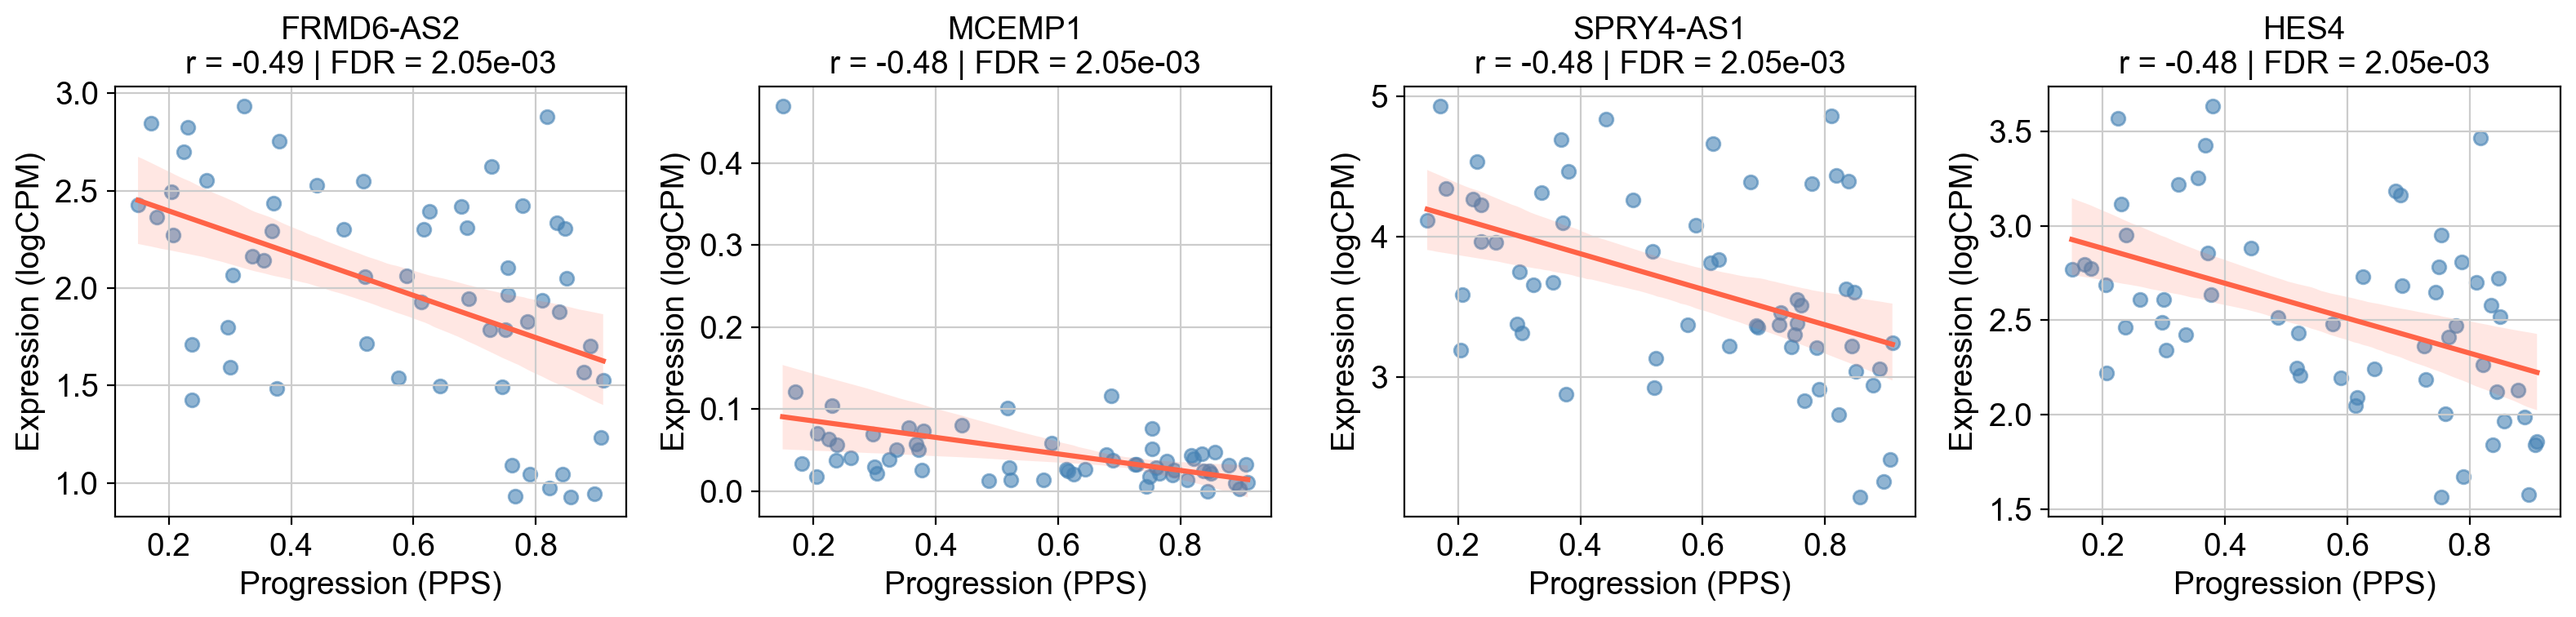

In [ ]:
print("Calcul des corrélations Expression ARN vs PPS...")

# 1. Préparation de la variable clinique (PPS)
# On s'assure que l'ordre des donneurs est bien le même
pps_values = donor_meta.loc[expr_mat.columns, 'Continuous Pseudo-progression Score'].values

# 2. Calcul des corrélations
results = []
for gene in expr_mat.index:
    expr = expr_mat.loc[gene].values
    
    # Corrélation de Spearman
    r, pval = stats.spearmanr(expr, pps_values)
    results.append({
        'gene': gene,
        'r': r,
        'pval': pval
    })

# 3. DataFrame et correction FDR (Benjamini-Hochberg)
res_df = pd.DataFrame(results).set_index('gene')
res_df = res_df.dropna() # Sécurité

# Correction pour les tests multiples (car on teste 77 gènes en même temps)
res_df['fdr'] = multipletests(res_df['pval'], method='fdr_bh')[1]

# Tri par p-value la plus significative
res_df = res_df.sort_values('pval')

print(f"Gènes significatifs (p-value < 0.05) : {(res_df['pval'] < 0.05).sum()}")
print(f"Gènes significatifs robustes (FDR < 0.05) : {(res_df['fdr'] < 0.05).sum()}")
print("\nTop 5 des gènes associés à la progression d'Alzheimer :")
display(res_df.head(5).round(4))

# 4. Sauvegarde des résultats complets
res_df.to_csv(f'{OUT_DIR_RNA}/RNA_vs_PPS_correlation_results.csv')

# 5. Visualisation des 4 meilleurs gènes
top_genes = res_df.head(4).index.tolist()

if len(top_genes) > 0:
    fig, axes = plt.subplots(1, len(top_genes), figsize=(4 * len(top_genes), 4))
    # Gère le cas où il n'y a qu'un seul gène
    if len(top_genes) == 1: axes = [axes] 
        
    for i, gene in enumerate(top_genes):
        sns.regplot(
            x=pps_values, 
            y=expr_mat.loc[gene], 
            ax=axes[i], 
            scatter_kws={'alpha':0.6, 'color':'steelblue'}, 
            line_kws={'color':'tomato'}
        )
        axes[i].set_title(f"{gene}\nr = {res_df.loc[gene,'r']:.2f} | FDR = {res_df.loc[gene,'fdr']:.2e}")
        axes[i].set_xlabel("Progression (PPS)")
        axes[i].set_ylabel("Expression (logCPM)")
        
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR_RNA}/top_genes_RNA_vs_PPS.png', dpi=150)
    plt.show()


In [ ]:
print("Étape 1 : Normalisation de la matrice ATAC en logCPM")

# 1. On extrait juste nos 59 donneurs en commun de la matrice ATAC brute
atac_mat = atac_df[common_donors]

# 2. Normalisation CPM (Counts Per Million) puis log1p
# On divise chaque compte par le total de son donneur, on multiplie par 1 million, puis log(x+1)
atac_mat_cpm = atac_mat.div(atac_mat.sum(axis=0), axis=1) * 1e6
atac_mat_logcpm = np.log1p(atac_mat_cpm)

# 3. Vérification visuelle
print("Valeur maximale AVANT normalisation :", atac_mat.max().max())
print("Valeur maximale APRÈS normalisation :", atac_mat_logcpm.max().max().round(2))

Étape 1 : Normalisation de la matrice ATAC en logCPM


NameError: name 'atac_df' is not defined

In [ ]:
print("Étape 2 : Recalcul des corrélations avec l'ATAC normalisée")

mapping_file = "../data/processed/results_aCM_AD/78cms_to_genes_CLEAN.csv"
df_mapping = pd.read_csv(mapping_file)

df_mapping['peak_coord'] = "chr" + df_mapping['chr_p'].astype(str) + ":" + df_mapping['start_p'].astype(str) + "-" + df_mapping['end_p'].astype(str)

# 3. Calcul des corrélations Spearman ATAC(logCPM) vs ARN(logCPM)
atac_rna_res = []

for idx, row in df_mapping.iterrows():
    cm_id = row['CM']
    peak_coord = row['peak_coord']
    gene = row['gene_name']
    
    # Vérification: Le pic est dans l'ATAC normalisé ? Le gène est dans l'ARN ?
    if peak_coord in atac_mat_logcpm.index and gene in expr_mat.index:
        atac_vals = atac_mat_logcpm.loc[peak_coord].values
        rna_vals = expr_mat.loc[gene].values
        
        r, pval = stats.spearmanr(atac_vals, rna_vals)
        atac_rna_res.append({
            'CM_id': cm_id,
            'peak_coord': peak_coord,
            'gene': gene,
            'r_atac_rna': r,
            'pval_atac_rna': pval
        })

# 4. Traitement du tableau
df_integ = pd.DataFrame(atac_rna_res)
# Nettoyage des éventuels doublons (même pic, même gène)
df_integ = df_integ.drop_duplicates(subset=['peak_coord', 'gene'])

if not df_integ.empty:
    # 5. Correction FDR (Benjamini-Hochberg) pour les tests multiples
    df_integ['fdr_atac_rna'] = multipletests(df_integ['pval_atac_rna'], method='fdr_bh')[1]
    
    # 6. Fusion finale avec les résultats Maladie (res_df)
    df_integ = df_integ.merge(res_df.reset_index(), on='gene', how='inner')
    df_integ = df_integ.rename(columns={'r': 'r_rna_pps', 'pval': 'pval_rna_pps', 'fdr': 'fdr_rna_pps'})
    
    # Tri par la significativité de la maladie, puis de l'ATAC
    df_integ = df_integ.sort_values(by=['fdr_rna_pps', 'pval_atac_rna'])
    
    print(f" Paires uniques testées (ATAC & RNA dispos) : {len(df_integ)}")
    print(f" Paires corrélées significativement (FDR < 0.05) : {(df_integ['fdr_atac_rna'] < 0.05).sum()}")
    print("\nTop 5 des paires :")
    display(df_integ.head(4))
    
    # On sauvegarde ce tableau qui est maintenant inattaquable !
    df_integ.to_csv(f'{OUT_DIR_RNA}/Master_Table_ATAC_RNA_PPS_Corrected.csv', index=False)

Étape 2 : Recalcul des corrélations avec l'ATAC normalisée
 Paires uniques testées (ATAC & RNA dispos) : 122
 Paires corrélées significativement (FDR < 0.05) : 77

Top 5 des paires :


,CM_id,peak_coord,gene,r_atac_rna,pval_atac_rna,fdr_atac_rna,r_rna_pps,pval_rna_pps,fdr_rna_pps
36,cm8237,chr7:101158619-101174695,NAT16,0.738282,2.509713e-11,7.654625e-10,-0.471128,0.000166,0.002049
52,cm11022,chr11:43572943-43584149,AC068205.1,0.666628,8.228688e-09,1.434143e-07,-0.467914,0.000186,0.002049
37,cm8237,chr7:101178809-101180980,NAT16,0.655465,1.764565e-08,2.391965e-07,-0.471128,0.000166,0.002049
23,cm6271,chr5:142542763-142543378,SPRY4-AS1,0.584395,1.176745e-06,8.947400e-06,-0.478434,0.000127,0.002049


In [ ]:
OUT_DIR_RNA = "../data/raw/SEA-AD/MTG_scRNA/results_aCM_AD"
df_integ = pd.read_csv(f'{OUT_DIR_RNA}/Master_Table_ATAC_RNA_PPS_Corrected.csv')

In [2]:
# --- Chemins ---
RNA_PATH = "../data/raw/SEAAD_MTG_RNAseq_all-nuclei.2024-02-13.h5ad"
ATAC_PATH = "../data/processed/count_matrix.txt"
OUT_DIR_RNA = "../data/raw/SEA-AD/MTG_scRNA/results_aCM_AD"

PB_PATH = f"{OUT_DIR_RNA}/pseudobulk_neurons_snRNA.csv"
MASTER_PATH = f"{OUT_DIR_RNA}/Master_Table_ATAC_RNA_PPS_Corrected.csv"

for p in [ATAC_PATH, PB_PATH, MASTER_PATH, RNA_PATH]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Fichier introuvable: {p}")

# --- 1) Tables déjà sauvegardées ---
atac_df = pd.read_csv(ATAC_PATH, sep="\t", index_col=0)
pb_df = pd.read_csv(PB_PATH, index_col=0)
df_integ = pd.read_csv(MASTER_PATH)

# --- 2) Métadonnées donneurs (PPS) depuis le h5ad (sans QC) ---
adata_rna = sc.read_h5ad(RNA_PATH)
donor_meta = (
    adata_rna.obs[["Donor ID", "Continuous Pseudo-progression Score"]]
    .dropna(subset=["Continuous Pseudo-progression Score"])
    .drop_duplicates(subset=["Donor ID"])
    .set_index("Donor ID")
)

# --- 3) Donneurs communs (ordre stable) ---
common_donors = [d for d in pb_df.columns if d in atac_df.columns and d in donor_meta.index]
if len(common_donors) == 0:
    raise ValueError("Aucun donneur commun entre ATAC / pseudobulk RNA / PPS.")

# --- 4) Matrice RNA (logCPM) alignée sur les donneurs communs ---
pb_cpm = pb_df.div(pb_df.sum(axis=0), axis=1) * 1e6
pb_logcpm = np.log1p(pb_cpm)

genes_needed = [g for g in df_integ["gene"].unique() if g in pb_logcpm.index]
expr_mat = pb_logcpm.loc[genes_needed, common_donors]

# --- 5) Matrice ATAC (logCPM) alignée ---
atac_mat = atac_df[common_donors]
atac_mat_cpm = atac_mat.div(atac_mat.sum(axis=0), axis=1) * 1e6
atac_mat_logcpm = np.log1p(atac_mat_cpm)

# --- 6) Réalignement final ---
donor_meta = donor_meta.loc[common_donors]

print(f"✅ Reprise prête")
print(f"   Donneurs communs : {len(common_donors)}")
print(f"   expr_mat         : {expr_mat.shape}")
print(f"   atac_mat_logcpm  : {atac_mat_logcpm.shape}")
print(f"   df_integ         : {df_integ.shape}")

✅ Reprise prête
   Donneurs communs : 59
   expr_mat         : (77, 59)
   atac_mat_logcpm  : (218882, 59)
   df_integ         : (122, 9)


Étape 3 : Génération des graphiques propres


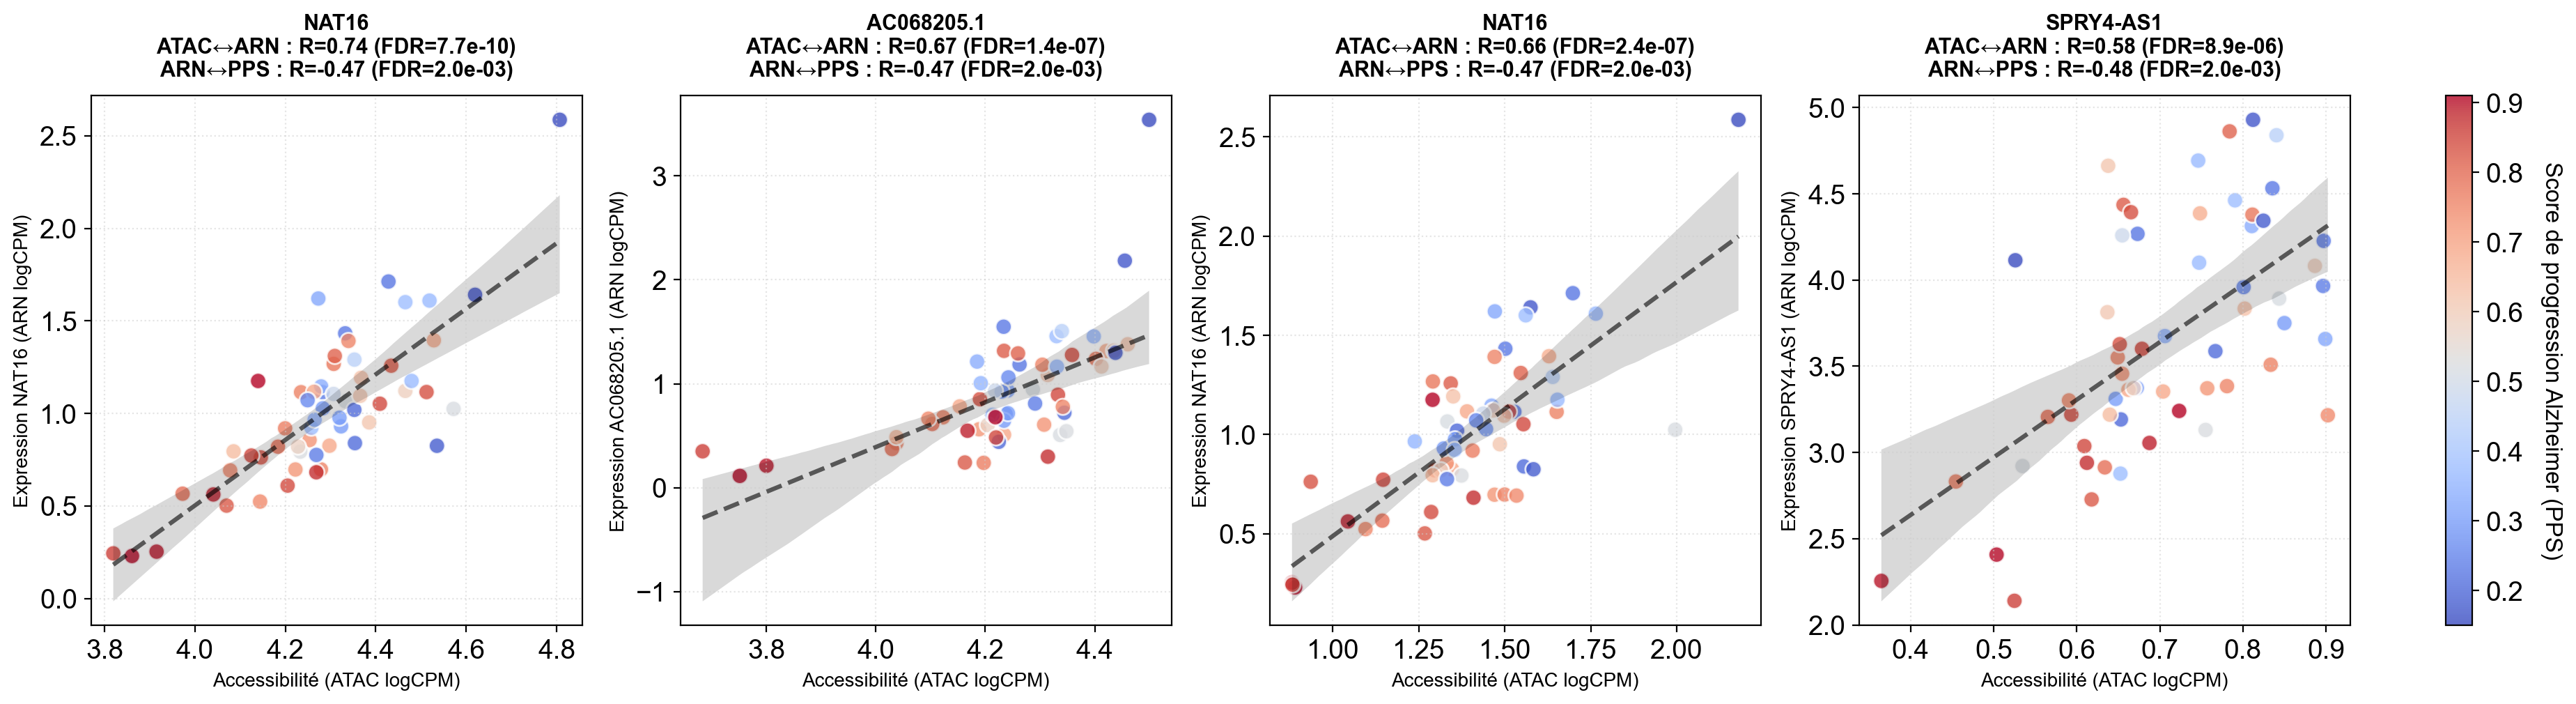

✅ Graphique final sauvegardé : ./SEA-AD/MTG_scRNA/results_aCM_AD/Top_Integration_Corrected.png


In [3]:
print("Étape 3 : Génération des graphiques propres")

# On sélectionne les 4 meilleures paires
N_PLOTS = 4
top_pairs = df_integ.head(N_PLOTS)

# On prépare la figure
fig, axes = plt.subplots(1, N_PLOTS, figsize=(5.5 * N_PLOTS, 5))
# Si N_PLOTS=1, plt.subplots ne renvoie pas un array, on le force
if N_PLOTS == 1: axes = [axes]

# Récupération du score d'Alzheimer (PPS) pour colorer les points
pps_scores = donor_meta.loc[common_donors, 'Continuous Pseudo-progression Score'].values

for i, (idx, row) in enumerate(top_pairs.iterrows()):
    ax = axes[i]
    peak = row['peak_coord']
    gene = row['gene']
    
    x_val = atac_mat_logcpm.loc[peak].values
    y_val = expr_mat.loc[gene].values
    
    # 1. Nuage de points
    scatter = ax.scatter(x_val, y_val, c=pps_scores, cmap='coolwarm', 
                         alpha=0.8, edgecolors='white', s=70)
    
    # 2. Ligne de tendance
    sns.regplot(x=x_val, y=y_val, ax=ax, scatter=False, 
                color='black', line_kws={'linestyle':'--', 'alpha':0.6})
    
    # 3. Titre (arrondi pour être propre)
    title = f"{gene}\n"
    title += f"ATAC↔ARN : R={row['r_atac_rna']:.2f} (FDR={row['fdr_atac_rna']:.1e})\n"
    title += f"ARN↔PPS : R={row['r_rna_pps']:.2f} (FDR={row['fdr_rna_pps']:.1e})"
    
    ax.set_title(title, fontsize=11, pad=10, fontweight='bold')
    ax.set_xlabel("Accessibilité (ATAC logCPM)", fontsize=10)
    ax.set_ylabel(f"Expression {gene} (ARN logCPM)", fontsize=10)
    
    # On ajoute une petite grille pour que ça soit plus lisible
    ax.grid(True, linestyle=':', alpha=0.5)

# Ajout de la légende de couleur (Score PPS)
cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.015, pad=0.04)
cbar.set_label("Score de progression Alzheimer (PPS)", rotation=270, labelpad=20, fontsize=12)

# Sauvegarde
plt.savefig(f'{OUT_DIR_RNA}/Top_Integration_Corrected.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Graphique final sauvegardé : {OUT_DIR_RNA}/Top_Integration_Corrected.png")


Étape 3 : Génération des graphiques - Ouverture vs Fermeture
Top gènes (Fermeture) trouvés : 4
Top gènes (Ouverture) trouvés : 4


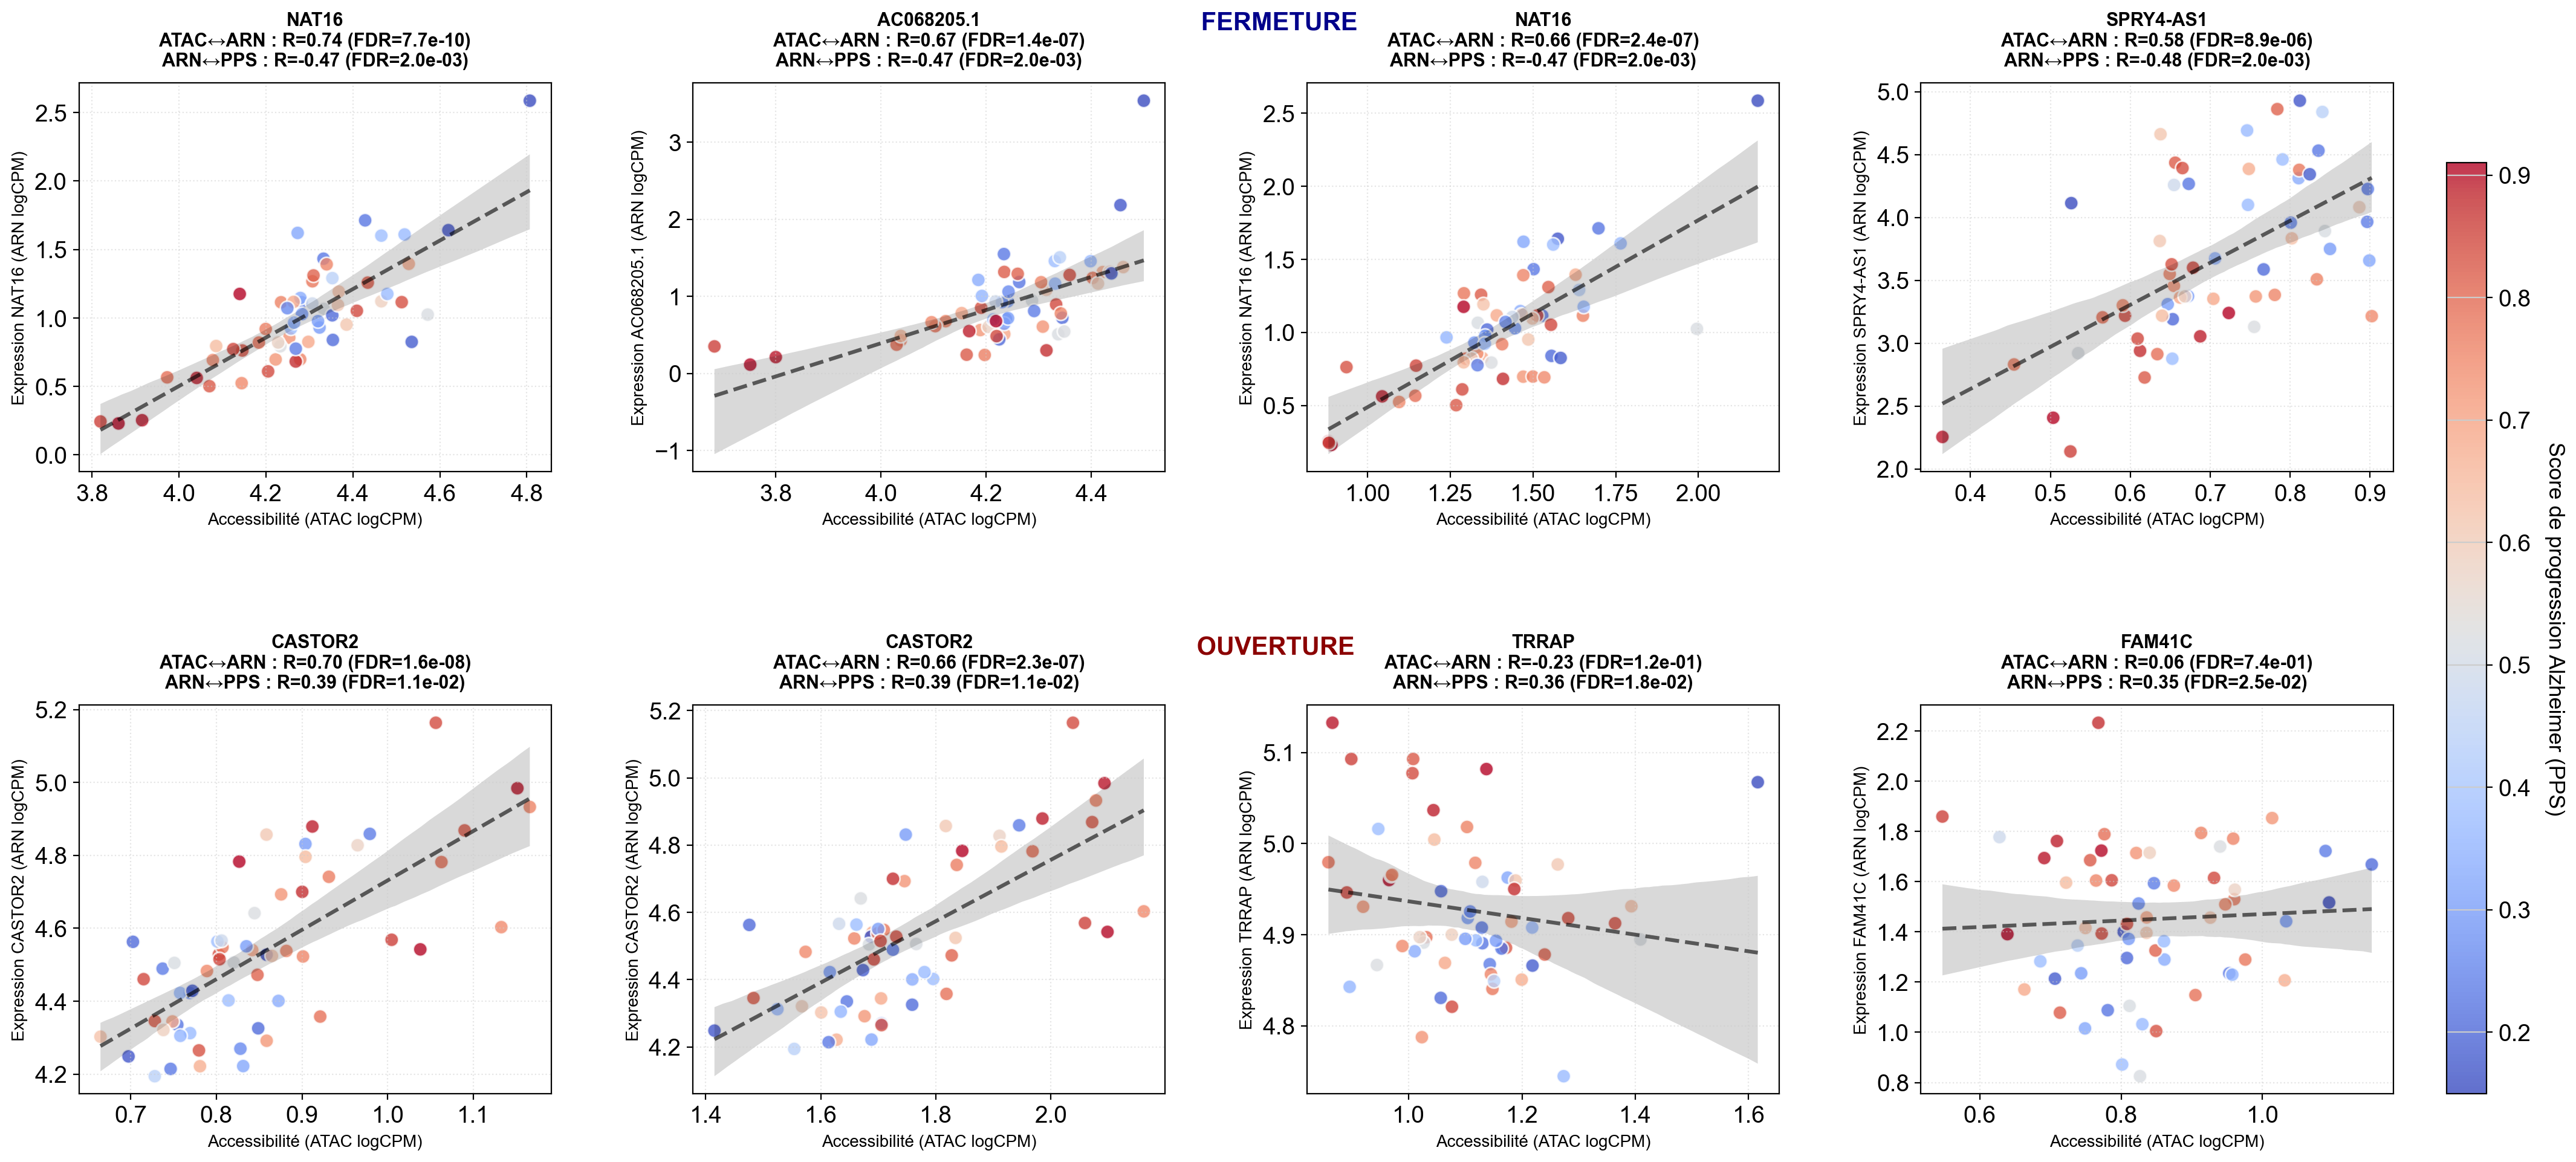

✅ Graphique comparatif sauvegardé : ./SEA-AD/MTG_scRNA/results_aCM_AD/Top_Integration_Fermeture_Ouverture.png


In [4]:
print("Étape 3 : Génération des graphiques - Ouverture vs Fermeture")

# 1. Séparer les gènes qui se ferment et ceux qui s'ouvrent
df_ferme = df_integ[df_integ['r_rna_pps'] < 0].head(4)
df_ouvre = df_integ[df_integ['r_rna_pps'] > 0].head(4)

print(f"Top gènes (Fermeture) trouvés : {len(df_ferme)}")
print(f"Top gènes (Ouverture) trouvés : {len(df_ouvre)}")

# 2. Préparer la grande figure (2 lignes, 4 colonnes)
fig, axes = plt.subplots(2, 4, figsize=(22, 11))
pps_scores = donor_meta.loc[common_donors, 'Continuous Pseudo-progression Score'].values

# On crée une liste pour itérer facilement sur nos deux groupes
groupes = [
    (0, df_ferme, " FERMETURE", 'darkblue'),
    (1, df_ouvre, " OUVERTURE ", 'darkred')
]

scatter = None # Pour garder en mémoire le graphique pour la barre de couleur

for row_idx, df_sub, titre_ligne, couleur in groupes:
    # Ajouter un titre pour la ligne au-dessus des graphiques
    fig.text(0.5, 0.95 if row_idx == 0 else 0.48, titre_ligne, 
             ha='center', fontsize=15, fontweight='bold', color=couleur)
    
    for col_idx in range(4):
        ax = axes[row_idx, col_idx]
        
        # S'il y a un gène à afficher dans cette case
        if col_idx < len(df_sub):
            row_data = df_sub.iloc[col_idx]
            peak = row_data['peak_coord']
            gene = row_data['gene']
            
            x_val = atac_mat_logcpm.loc[peak].values
            y_val = expr_mat.loc[gene].values
            
            # Nuage de points
            scatter = ax.scatter(x_val, y_val, c=pps_scores, cmap='coolwarm', 
                                 alpha=0.8, edgecolors='white', s=70)
            
            # Ligne de tendance
            sns.regplot(x=x_val, y=y_val, ax=ax, scatter=False, 
                        color='black', line_kws={'linestyle':'--', 'alpha':0.6})
            
            # Titre du subplot
            title = f"{gene}\n"
            title += f"ATAC↔ARN : R={row_data['r_atac_rna']:.2f} (FDR={row_data['fdr_atac_rna']:.1e})\n"
            title += f"ARN↔PPS : R={row_data['r_rna_pps']:.2f} (FDR={row_data['fdr_rna_pps']:.1e})"
            
            ax.set_title(title, fontsize=11, pad=10, fontweight='bold')
            ax.set_xlabel("Accessibilité (ATAC logCPM)", fontsize=10)
            ax.set_ylabel(f"Expression {gene} (ARN logCPM)", fontsize=10)
            ax.grid(True, linestyle=':', alpha=0.5)
            
        else:
            # S'il n'y a pas assez de gènes, on cache la case vide
            ax.set_visible(False)

# 3. Ajout de la barre de couleur globale (à droite)
# On ajuste l'espacement pour laisser de la place à la colorbar et aux titres
plt.subplots_adjust(left=0.05, right=0.92, hspace=0.6, wspace=0.3)

if scatter is not None:
    cbar_ax = fig.add_axes([0.94, 0.15, 0.015, 0.7]) # [left, bottom, width, height]
    cbar = fig.colorbar(scatter, cax=cbar_ax, orientation='vertical')
    cbar.set_label("Score de progression Alzheimer (PPS)", rotation=270, labelpad=20, fontsize=13)

# Sauvegarde
plt.savefig(f'{OUT_DIR_RNA}/Top_Integration_Fermeture_Ouverture.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Graphique comparatif sauvegardé : {OUT_DIR_RNA}/Top_Integration_Fermeture_Ouverture.png")

Recherche des Super-Enhancers (CM contrôlant plusieurs gènes) et génération des graphiques...
✅ Trouvé 6 Super-Enhancers contrôlant plusieurs gènes !


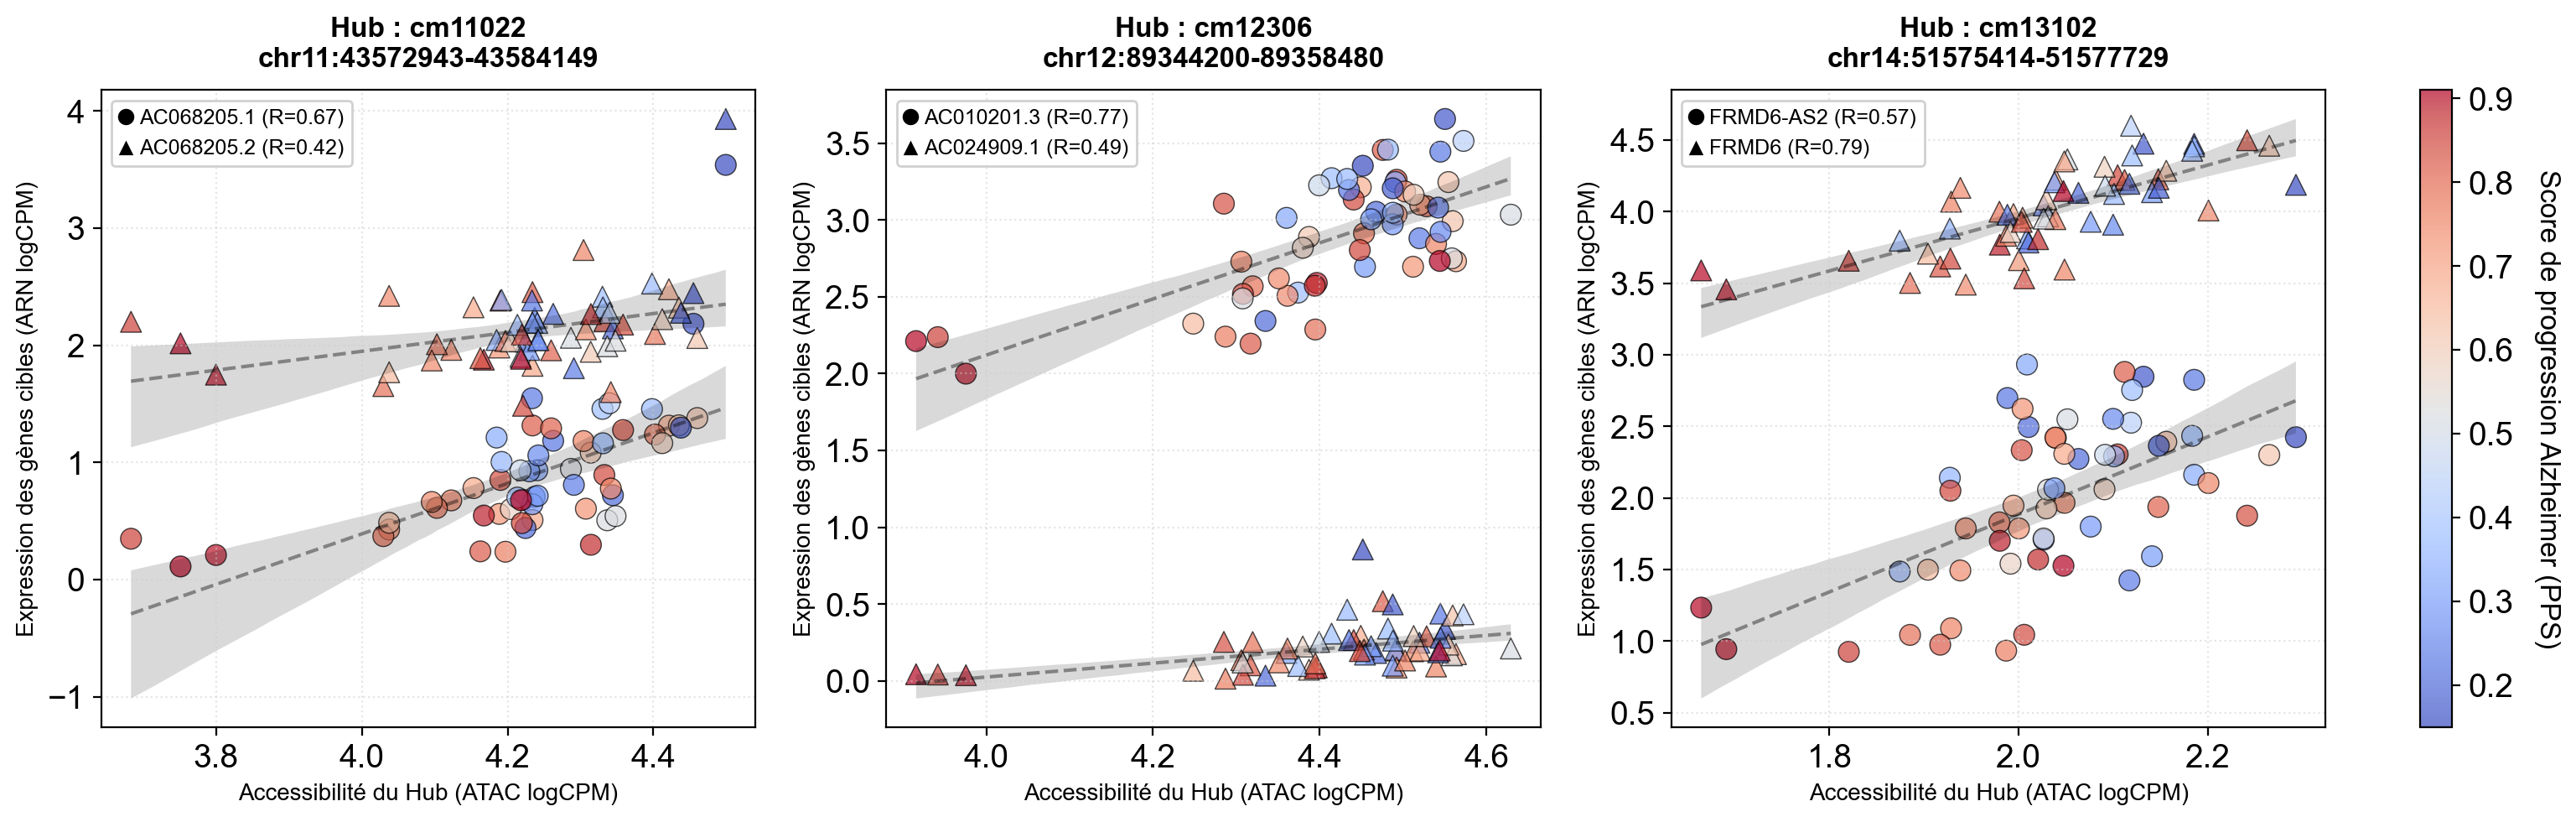

✅ Graphique des Hubs sauvegardé : ./SEA-AD/MTG_scRNA/results_aCM_AD/Hubs_Coregulation.png


In [5]:
print("Recherche des Super-Enhancers (CM contrôlant plusieurs gènes) et génération des graphiques...")

# 1. On filtre pour ne garder que les résultats très robustes (FDR < 0.05 sur les 2 axes)
df_sig = df_integ[(df_integ['fdr_atac_rna'] < 0.05) & (df_integ['fdr_rna_pps'] < 0.05)].copy()

# 2. On regroupe par CM_id et peak_coord pour trouver les "Hubs"
hubs = df_sig.groupby(['CM_id', 'peak_coord']).agg(
    genes=('gene', list),
    nb_genes=('gene', 'count')
).reset_index()

# On ne garde que les CM qui contrôlent au moins 2 gènes et on trie
hubs = hubs[hubs['nb_genes'] > 1].sort_values('nb_genes', ascending=False)

if hubs.empty:
    print("⚠️ Aucun CM ne contrôle plusieurs gènes avec un FDR < 0.05 dans tes données.")
else:
    print(f"✅ Trouvé {len(hubs)} Super-Enhancers contrôlant plusieurs gènes !")
    
    # On va tracer les 3 meilleurs Hubs (ou moins s'il y en a moins)
    N_PLOTS = min(3, len(hubs))
    fig, axes = plt.subplots(1, N_PLOTS, figsize=(6 * N_PLOTS, 5))
    if N_PLOTS == 1: axes = [axes]
        
    pps_scores = donor_meta.loc[common_donors, 'Continuous Pseudo-progression Score'].values
    
    # Liste de marqueurs pour différencier les gènes (Rond, Triangle, Carré, Étoile)
    markers = ['o', '^', 's', '*']
    
    for i in range(N_PLOTS):
        ax = axes[i]
        hub_row = hubs.iloc[i]
        cm_id = hub_row['CM_id']
        peak = hub_row['peak_coord']
        genes = hub_row['genes']
        
        # On récupère l'ATAC (axe X) qui est commun à tous les gènes de ce CM
        x_val = atac_mat_logcpm.loc[peak].values
        
        # Pour stocker les éléments pour la légende
        legend_handles = []
        
        for j, gene in enumerate(genes):
            # On s'assure de ne pas dépasser le nombre de marqueurs dispos
            marker = markers[j % len(markers)] 
            y_val = expr_mat.loc[gene].values
            
            # Nuage de points pour ce gène
            scatter = ax.scatter(x_val, y_val, c=pps_scores, cmap='coolwarm', 
                                 alpha=0.7, edgecolors='black', s=80, marker=marker,
                                 linewidth=0.5, label=gene)
            
            # Ligne de tendance pour ce gène
            # On récupère la corrélation depuis df_sig pour le titre de la légende
            corr_row = df_sig[(df_sig['CM_id'] == cm_id) & (df_sig['gene'] == gene)].iloc[0]
            r_atac_rna = corr_row['r_atac_rna']
            
            sns.regplot(x=x_val, y=y_val, ax=ax, scatter=False, 
                        color='black', line_kws={'linestyle':'--', 'alpha':0.4, 'linewidth': 1.5})
            
            # On garde juste un point noir vide pour la légende du gène
            legend_handles.append(plt.Line2D([0], [0], marker=marker, color='w', 
                                           markerfacecolor='black', markersize=8, 
                                           label=f"{gene} (R={r_atac_rna:.2f})"))
            
        ax.set_title(f"Hub : {cm_id}\n{peak}", fontsize=12, pad=10, fontweight='bold')
        ax.set_xlabel("Accessibilité du Hub (ATAC logCPM)", fontsize=10)
        ax.set_ylabel("Expression des gènes cibles (ARN logCPM)", fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.5)
        
        # Ajout de la légende des formes (en haut à gauche)
        ax.legend(handles=legend_handles, loc='upper left', fontsize=9, framealpha=0.9)

    # Barre de couleur (PPS)
    cbar = fig.colorbar(scatter, ax=axes.ravel().tolist(), orientation='vertical', fraction=0.015, pad=0.04)
    cbar.set_label("Score de progression Alzheimer (PPS)", rotation=270, labelpad=20, fontsize=12)

    
    plt.savefig(f'{OUT_DIR_RNA}/Hubs_Coregulation.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Graphique des Hubs sauvegardé : {OUT_DIR_RNA}/Hubs_Coregulation.png")
